In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='dark', palette='bright', context='notebook')

ARQUIVO_DADOS = 'base/churn_clientes.csv'

df_churn = pd.read_csv(ARQUIVO_DADOS)
df_churn = df_churn.drop(columns='id_cliente', axis=1)


colunas_numericas = df_churn.select_dtypes(include='number').columns
colunas_categoricas = df_churn.select_dtypes(exclude='number').columns
colunas_categoricas = colunas_categoricas.drop('churn')

df_churn.head()

,genero,idoso,tem_parceiro,tem_dependentes,meses_na_empresa,servico_telefone,multiplas_linhas,servico_internet,servico_seguranca,servico_backup,servico_protecao_equipamento,servico_suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,forma_pagamento,valor_mensal,total_gasto,churn
0,Feminino,Não,Sim,Não,1,Não,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Boleto,29.85,29.85,Não
1,Masculino,Não,Não,Não,34,Sim,Não,DSL,Sim,Não,Sim,Não,Não,Não,Anual,Não,Cheque,56.95,1889.50,Não
2,Masculino,Não,Não,Não,2,Sim,Não,DSL,Sim,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque,53.85,108.15,Sim
3,Masculino,Não,Não,Não,45,Não,Não,DSL,Sim,Não,Sim,Sim,Não,Não,Anual,Não,Transferencia,42.30,1840.75,Não
4,Feminino,Não,Não,Não,2,Sim,Não,Fibra optica,Não,Não,Não,Não,Não,Não,Mensal,Sim,Boleto,70.70,151.65,Sim


In [2]:
print(colunas_categoricas)
print(len(colunas_categoricas))

Index(['genero', 'idoso', 'tem_parceiro', 'tem_dependentes',
       'servico_telefone', 'multiplas_linhas', 'servico_internet',
       'servico_seguranca', 'servico_backup', 'servico_protecao_equipamento',
       'servico_suporte_tecnico', 'streaming_tv', 'streaming_filmes',
       'contrato', 'fatura_digital', 'forma_pagamento'],
      dtype='object')
16


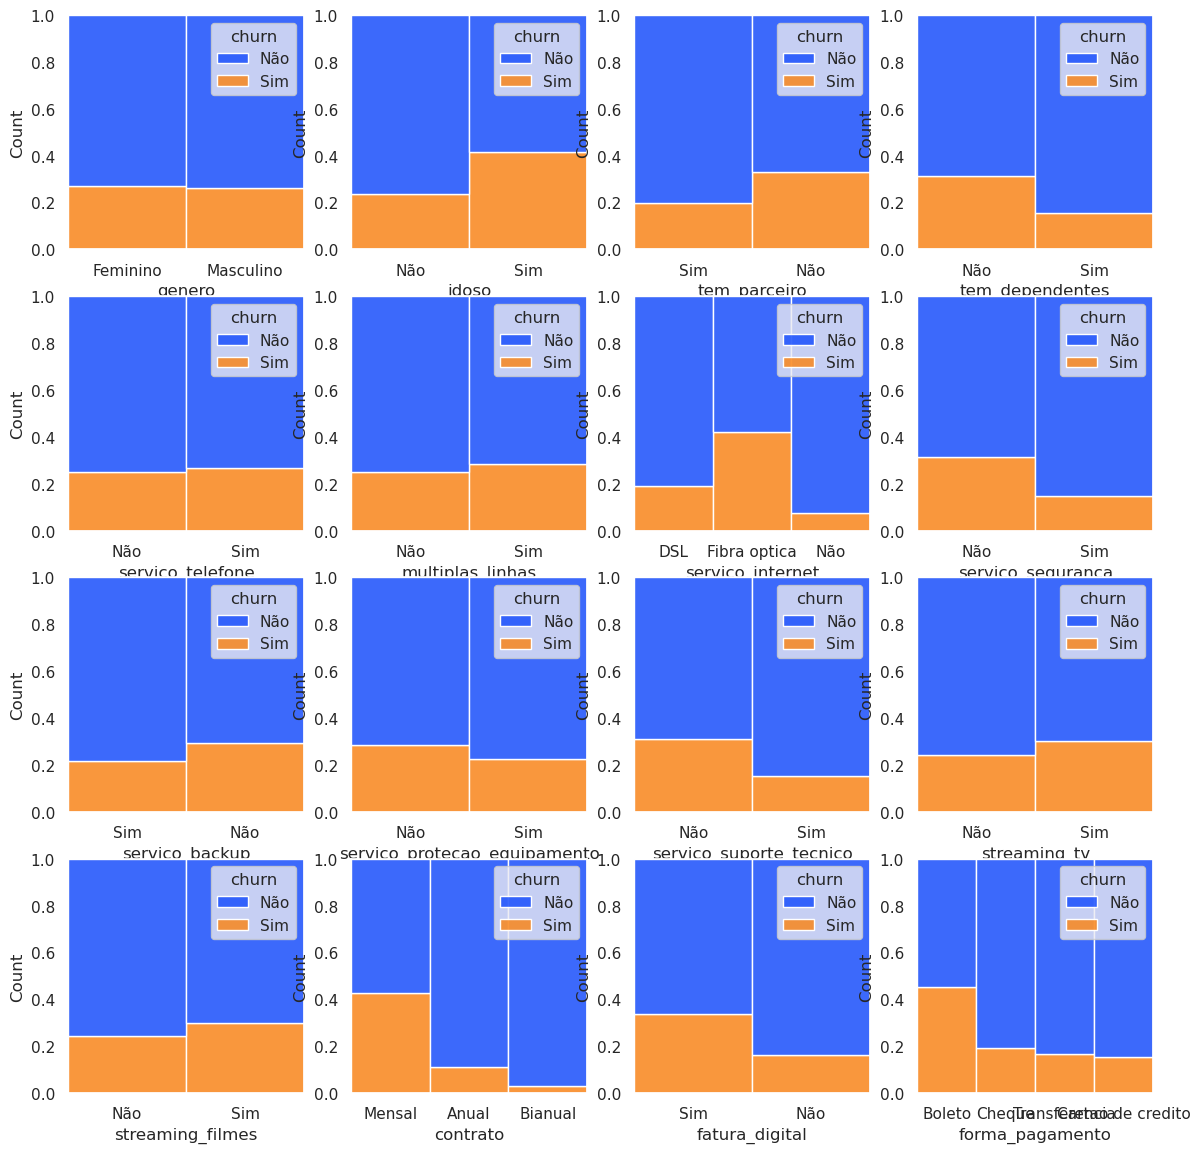

In [9]:
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 14))

for i, coluna in enumerate(colunas_categoricas):
    sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i])

plt.show()

In [6]:
print(axs)

[[<Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: >]
 [<Axes: > <Axes: > <Axes: > <Axes: >]]


In [5]:
print(list(axs.flat))

[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]


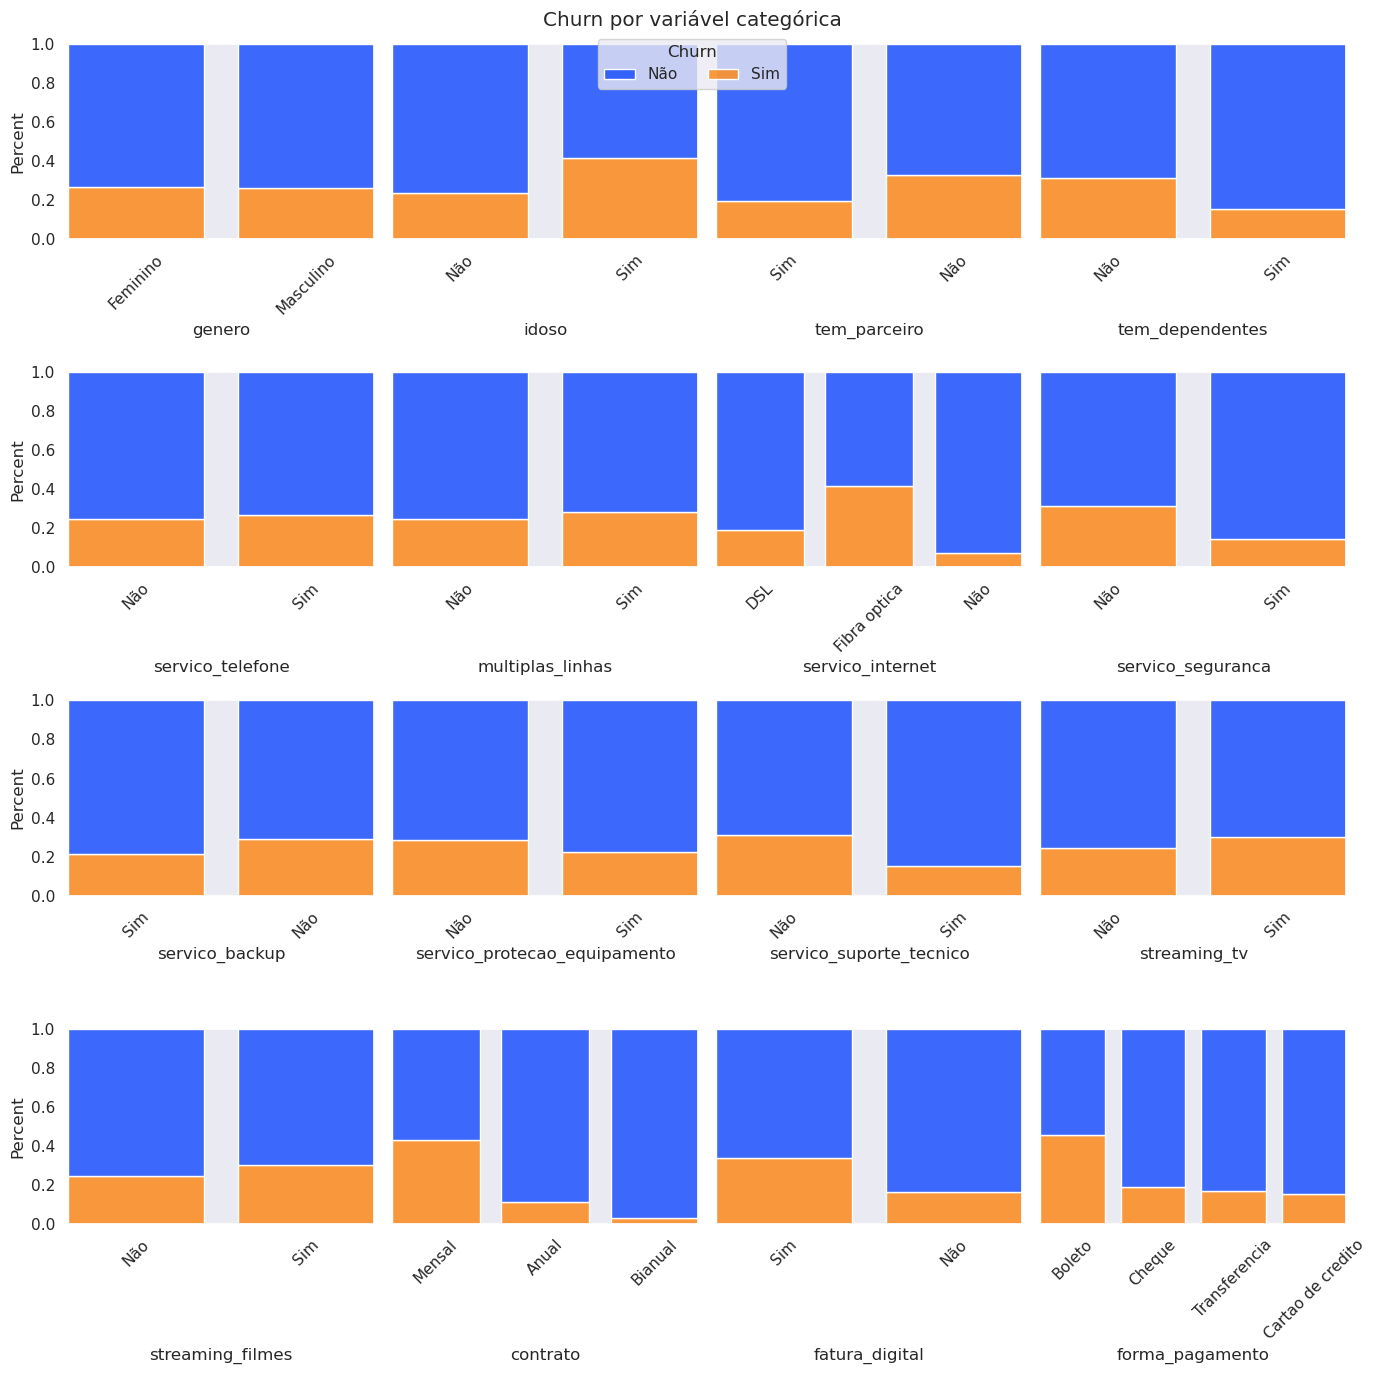

In [22]:
fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 14), sharey=True,  tight_layout=True)

for i, coluna in enumerate(colunas_categoricas):
   h = sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i], stat="percent", shrink=0.8)
   h.tick_params(axis="x", labelrotation=45)
   legenda = h.get_legend()
   legenda.remove()

rotulos = [text.get_text() for text in legenda.get_texts()]

fig.legend(handles=legenda.legend_handles, labels=rotulos, loc="upper center", ncols=2, title="Churn", bbox_to_anchor=(0.5, 0.965))
fig.suptitle("Churn por variável categórica")
   

fig.align_labels()


plt.show()

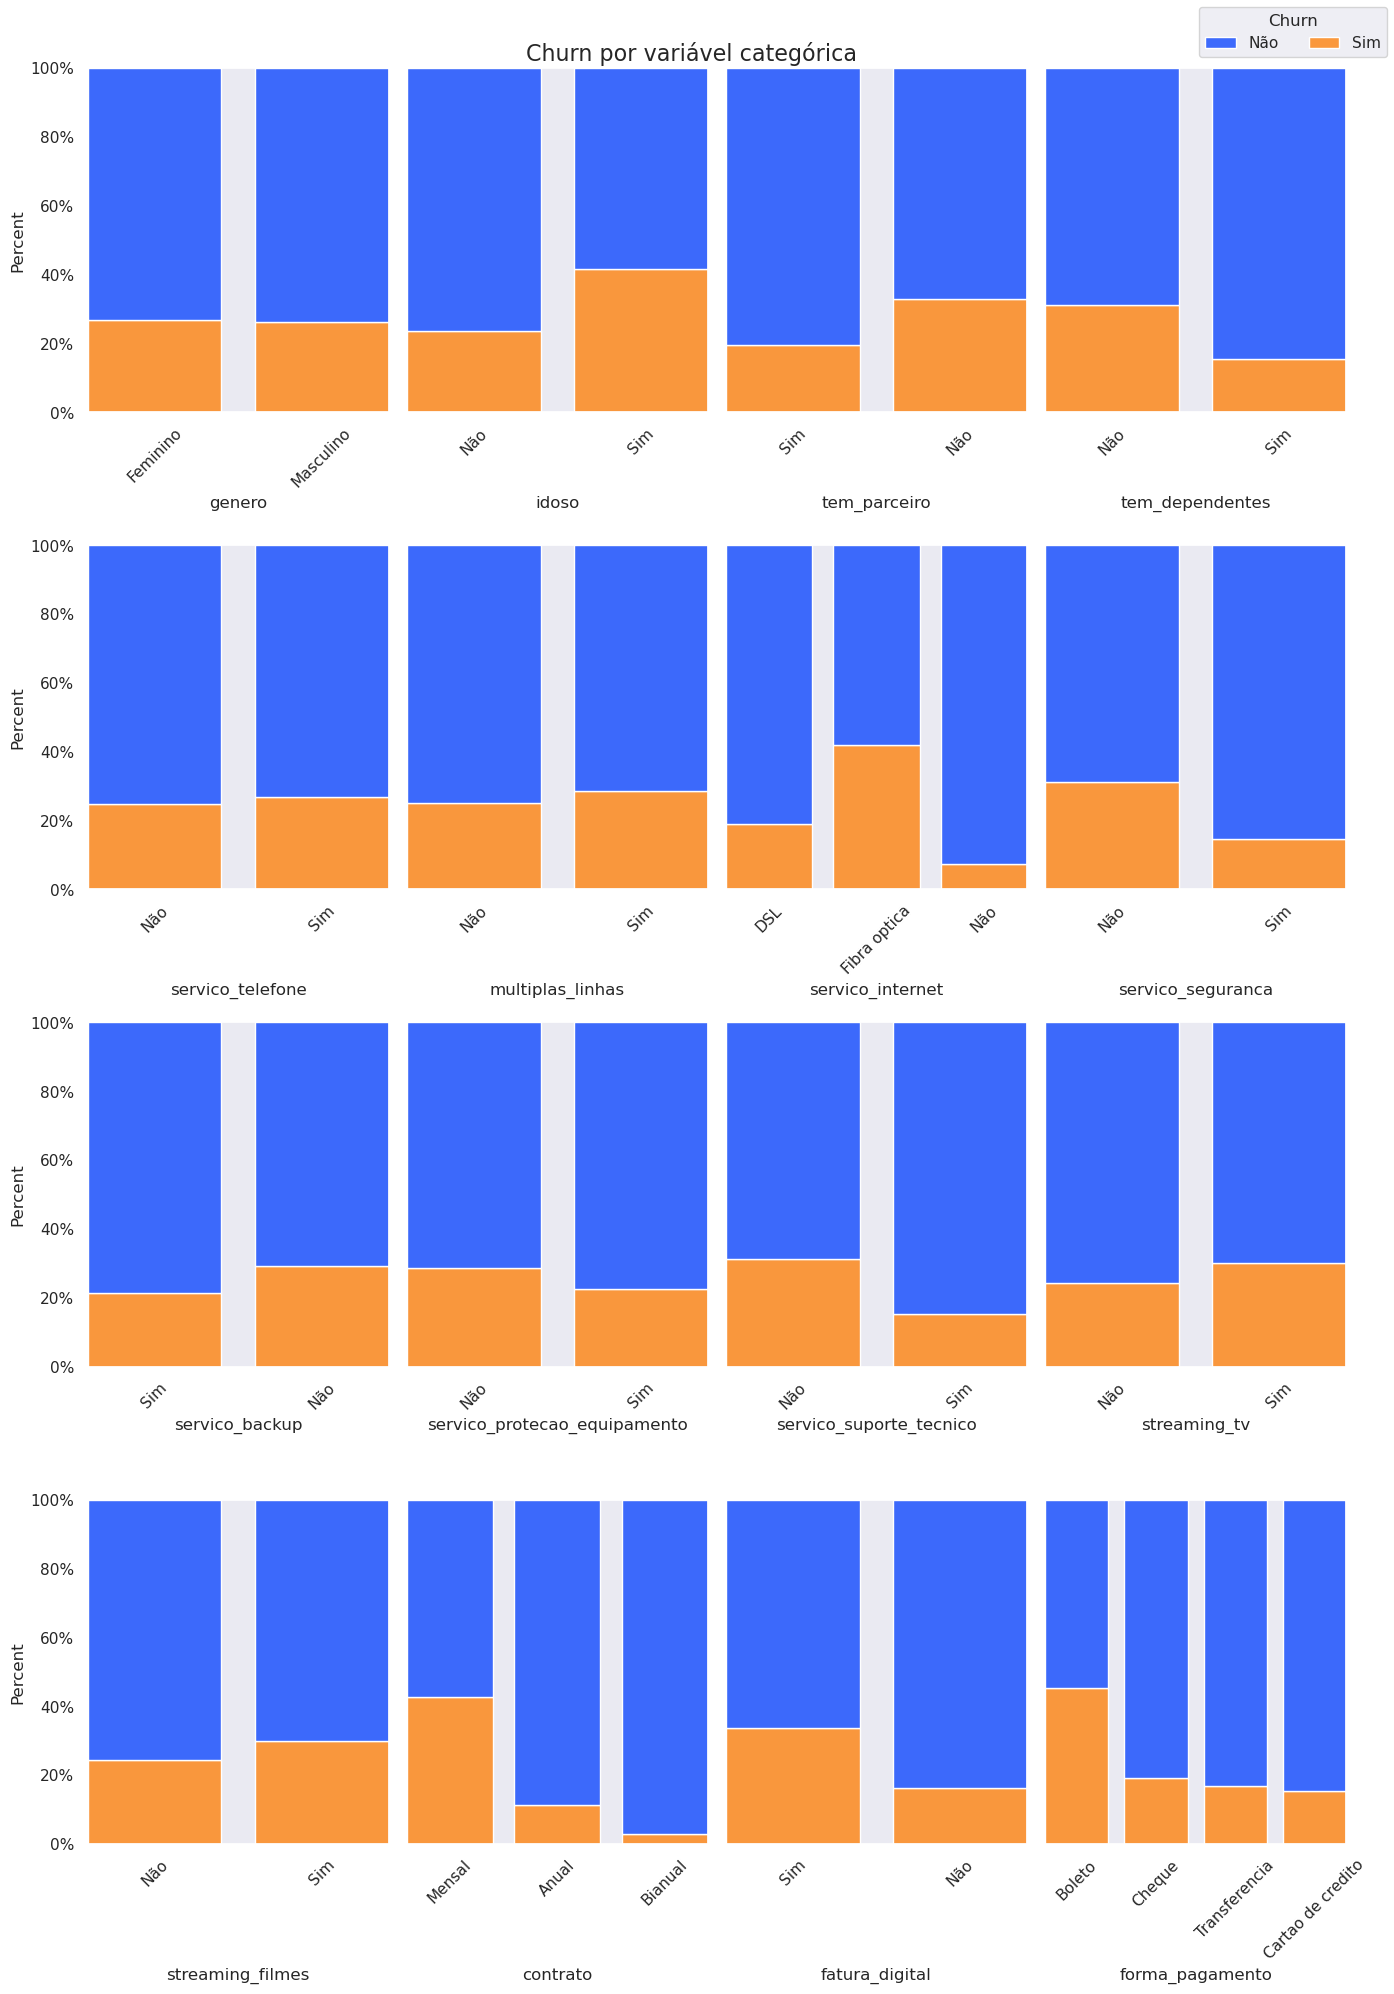

In [36]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(ncols=4, nrows=4, figsize=(14, 20), sharey=True,  tight_layout=True)

for i, coluna in enumerate(colunas_categoricas):
   h = sns.histplot(x=coluna, data=df_churn, hue="churn", multiple="fill", ax=axs.flat[i], stat="percent", 
                    shrink=0.8, common_norm=True)
   h.tick_params(axis="x", labelrotation=45)
   h.grid(False)

   legend = h.get_legend()
   legend.remove()

   h.yaxis.set_major_formatter(PercentFormatter(1))

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc="upper right", ncols=10, title="Churn")
fig.suptitle("Churn por variável categórica", fontsize=16)


fig.align_labels()


plt.show()